# Analysis

In [2]:
import pandas as pd

blocks_gdf = pd.read_pickle('./../data/saint_petersburg/blocks.pickle')
blocks_gdf['land_use'] = blocks_gdf.apply(lambda s : s['land_use'] if s['share'] > 0 else None, axis=1)

## ANOVA

**Вывод**: между группами (`land_use`) существуют статистически значимые различия

In [3]:
import pandas as pd
from scipy import stats
from blocksnet.enums import LandUse

def anova(column : str) -> tuple[float, float]:
    groups = []

    for land_use in LandUse:
        values = blocks_gdf[blocks_gdf.land_use == land_use][column].values
        groups.append(values)

    return stats.f_oneway(*groups)

def interpret_p_val(p_val : float) -> str:
    if p_val < 0.05:
        return 'Есть статистически значимые различия между группами'
    return 'Недостаточно доказательств, чтобы утверждать, что средние различаются'

data = []
for column in ['footprint_area', 'build_floor_area', 'living_area']:
    f_val, p_val = anova(column)
    data.append({
        'parameter': column,
        'f_val': f_val,
        'p_val': p_val,
        'desc': interpret_p_val(p_val)
    })
    
pd.DataFrame(data).set_index('parameter')

,f_val,p_val,desc
parameter,,,
footprint_area,254.672200,8.354609e-303,Есть статистически значимые различия между гру...
build_floor_area,116.695623,1.231977e-142,Есть статистически значимые различия между гру...
living_area,112.834582,5.624955e-138,Есть статистически значимые различия между гру...


## Индекс Морана

In [23]:
import geopandas as gpd
import libpysal
from esda.moran import Moran, Moran_Local

gdf = blocks_gdf.copy()

w = libpysal.weights.Queen.from_dataframe(gdf, use_index=True)
w.transform = 'r'

results = []
for param in ['footprint_area', 'build_floor_area', 'living_area']:
    
    moran = Moran(gdf[param], w)
    results.append({
        'parameter': param,
        "Moran_I": moran.I,
        "p_value": moran.p_sim
    })

    moran_loc = Moran_Local(gdf[param], w)
    gdf[f'{param}_moran'] = moran_loc.Is
    gdf[f'{param}_p'] = moran_loc.p_sim    

    cluster_labels = []
    for q, p_val in zip(moran_loc.q, moran_loc.p_sim):
        if p_val >= 0.05:
            cluster_labels.append(None)  # not significant
        else:
            if q == 1:
                cluster_labels.append("High-High")
            elif q == 2:
                cluster_labels.append("Low-High")
            elif q == 3:
                cluster_labels.append("High-Low")
            elif q == 4:
                cluster_labels.append("Low-Low")
    gdf[f'{param}_cluster'] = cluster_labels

/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 223 disconnected components.
 There are 182 islands with ids: 157, 380, 381, 510, 944, 1260, 1425, 1443, 1465, 1921, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 2599, 2630, 3307, 3308, 3309, 3310, 3311, 3314, 3328, 3329, 3332, 3333, 3334, 3335, 3359, 3360, 3363, 3364, 3365, 3366, 3367, 3368, 3369, 3370, 3378, 3379, 3380, 3396, 3397, 3400, 3401, 3407, 3410, 3411, 3449, 3450, 3453, 3454, 3455, 3461, 3483, 3553, 3814, 3826, 3827, 3934, 3945, 4088, 4089, 4090, 4091, 4092, 4093, 4094, 4095, 4096, 4097, 4098, 4099, 4100, 4101, 4102, 4103, 4104, 4105, 4106, 4107, 4108, 4109, 4110, 4111, 4112, 4163, 4241, 4327, 4328, 4359, 4365, 4366, 4385, 4386, 4387, 4388, 4576, 4577, 4578, 4850, 4851, 5028, 5029, 5030, 5031, 5049, 5050, 5122, 5123, 5124, 5125, 5126, 5127, 5128, 5129, 5158, 5159, 5160, 5183,

('WARNING: ', 157, ' is an island (no neighbors)')
('WARNING: ', 380, ' is an island (no neighbors)')
('WARNING: ', 381, ' is an island (no neighbors)')
('WARNING: ', 510, ' is an island (no neighbors)')
('WARNING: ', 944, ' is an island (no neighbors)')
('WARNING: ', 1260, ' is an island (no neighbors)')
('WARNING: ', 1425, ' is an island (no neighbors)')
('WARNING: ', 1443, ' is an island (no neighbors)')
('WARNING: ', 1465, ' is an island (no neighbors)')
('WARNING: ', 1921, ' is an island (no neighbors)')
('WARNING: ', 1963, ' is an island (no neighbors)')
('WARNING: ', 1964, ' is an island (no neighbors)')
('WARNING: ', 1965, ' is an island (no neighbors)')
('WARNING: ', 1966, ' is an island (no neighbors)')
('WARNING: ', 1967, ' is an island (no neighbors)')
('WARNING: ', 1968, ' is an island (no neighbors)')
('WARNING: ', 1969, ' is an island (no neighbors)')
('WARNING: ', 1970, ' is an island (no neighbors)')
('WARNING: ', 1971, ' is an island (no neighbors)')
('WARNING: ', 197

/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/esda/moran.py:1350: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/esda/moran.py:1350: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/esda/moran.py:1350: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


Интерпретация:
- `Moran_I` -- положительная слабая-умеренная (`[0.1, 0.3]`, `[0.3, 0.5]`) автокорреляция , похожие значения сгруппированы (`High-High`, `Low-Low`)
- `p_value` -- статистически значимые различия, автокорреляция реальна, а не случайна (`< 0.05`) 

In [24]:
import pandas as pd
results_df = pd.DataFrame(results).set_index('parameter')
results_df

,Moran_I,p_value
parameter,,
footprint_area,0.250678,0.001
build_floor_area,0.337822,0.001
living_area,0.332009,0.001


В пространстве можно выделить кластеры по отдельным параметрам

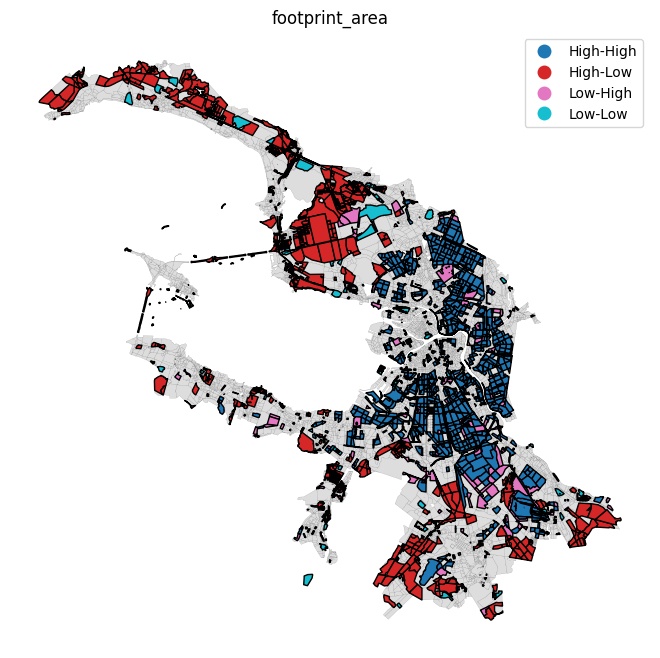

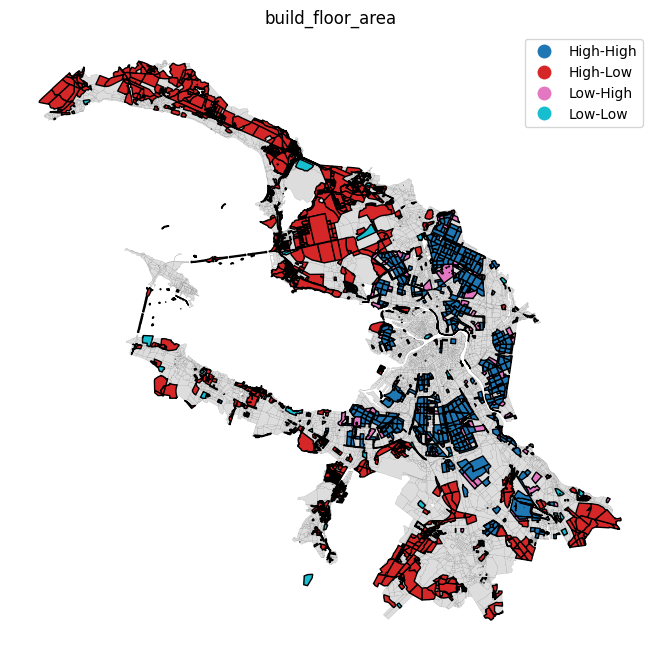

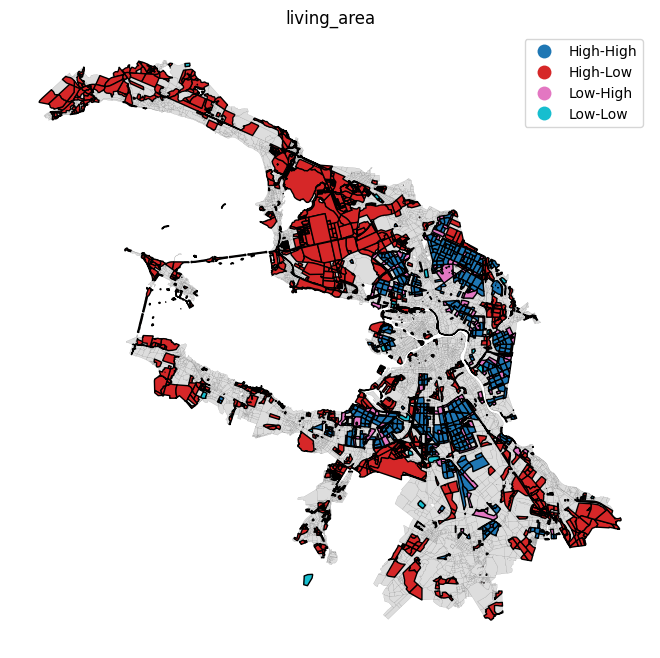

In [25]:
for column in ['footprint_area', 'build_floor_area', 'living_area']:
    ax = gdf.plot(color='#ddd', figsize=(10,8), linewidth=0.05, edgecolor='black')
    gdf.plot(f'{column}_cluster', ax=ax, figsize=(10,8), legend=True, linewidth=1, edgecolor='black')
    ax.set_axis_off()
    ax.set_title(column)

## Корреляция Пирсона

Параметры слабо зависят от `site_area` (площади застройки), но при этом хорошо коррелируют друг с другом.

In [28]:
import pandas as pd

# Выбираем колонки для анализа
params = ['site_area', 'footprint_area', 'build_floor_area', 'living_area']

# Считаем корреляционную матрицу (Пирсон)
corr_matrix = blocks_gdf[params].corr(method='pearson')
corr_matrix

,site_area,footprint_area,build_floor_area,living_area
site_area,1.000000,0.278336,0.193721,0.128083
footprint_area,0.278336,1.000000,0.741672,0.441422
build_floor_area,0.193721,0.741672,1.000000,0.886552
living_area,0.128083,0.441422,0.886552,1.000000
